In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random
import os

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.initializers import HeUniform
from tensorflow.keras.initializers import GlorotUniform

from tensorflow.keras.optimizers import Adam
from scipy.optimize import minimize
from scipy.optimize import fsolve

import scienceplots
plt.style.use(['science','bright'])
# plt.style.use(['science', 'std-colors'])
plt.rcParams.update({'figure.dpi': '150'})
mcolors = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.style.use(['no-latex']) 

2026-05-24 01:41:22.780311: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-24 01:41:22.785811: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779567082.792125  180265 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779567082.794227  180265 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779567082.799820  180265 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:

# ============================================================
#   GLOBAL DETERMINISM
# ============================================================
seed = 14
os.environ['PYTHONHASHSEED'] = str(seed)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)


In [3]:
# === USER FLAG TO CHOOSE DEVICE ===
use_gpu = False # Set to False to force CPU

# === Automatically choose device string ===
device = '/GPU:0' if use_gpu and tf.config.list_physical_devices('GPU') else '/CPU:0'
print(f"Running on device: {device}")

Running on device: /CPU:0


In [4]:
def exact_sine_solution(x, t):
    def implicit_eq(u, x0, t0):
        return u - np.sin(2 * np.pi * (x0 - u * t0))
    
    u_exact = np.zeros_like(x)
    for i in range(len(x)):
        u_guess = np.sin(2 * np.pi * x[i])  # initial guess based on IC
        u_exact[i] = fsolve(implicit_eq, u_guess, args=(x[i], t))[0]
    return u_exact


In [5]:

# Noise token if needed (currently unused)
noise_token = 0

# Load validation data
validation_data = np.loadtxt('validation_data.txt')
dim = 1
x = validation_data[:, :dim]
# u0 = validation_data[:, dim].copy()

# Grid and time-step setup
nx = x.shape[0]
L = np.max(x) - np.min(x)
dx = L / nx
c = 1.0
CFL = 0.95
dt = CFL * dx / c
convection_time = L / c
time = 1 * convection_time
nt = int(time / dt)
print(f"dx = {dx:.5f}, nx = {nx}, dt = {dt:.5f}, nt = {nt}, total time = {time:.3f}")


dx = 0.00498, nx = 201, dt = 0.00473, nt = 211, total time = 1.000


In [6]:

# Initial condition



def u_initial_sine(X):
    pi = tf.acos(-1.0)
    F = tf.sin(2.0 * pi * X)
    scale = tf.reduce_max(tf.abs(F))
    return F / scale





In [7]:
class PINN(tf.keras.Model):
    def __init__(self, input_dim=2, output_dim=1, use_bias=True):
        super().__init__()
        xavier_init = GlorotUniform(seed=seed)
        act = 'tanh'
        self.net = Sequential([
            Dense(100, input_shape=(input_dim,), activation=act, use_bias=use_bias, kernel_initializer=xavier_init),
            Dense(100, activation=act, use_bias=use_bias, kernel_initializer=xavier_init),
            Dense(100, activation=act, use_bias=use_bias, kernel_initializer=xavier_init),
            Dense(100, activation=act, use_bias=use_bias, kernel_initializer=xavier_init),
            Dense(100, activation=act, use_bias=use_bias, kernel_initializer=xavier_init),
            Dense(100, activation=act, use_bias=use_bias, kernel_initializer=xavier_init),
            Dense(100, activation=act, use_bias=use_bias, kernel_initializer=xavier_init),
            Dense(100, activation=act, use_bias=use_bias, kernel_initializer=xavier_init),
            Dense(output_dim, use_bias=use_bias, kernel_initializer=xavier_init)
        ])

    def call(self, X):
        return self.net(X)


def burgers_residual(model, x, t):
    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch([x, t])
        with tf.GradientTape(persistent=True) as tape1:
            tape1.watch([x, t])
            u = model(tf.concat([x, t], axis=1))
        u_x = tape1.gradient(u, x)
        u_t = tape1.gradient(u, t)
        u_xx = tape2.gradient(u_x, x)
        mu = 0.01 / np.pi
        # mu = 0.0
        del tape1
        del tape2
    return u_t + u * u_x - mu * u_xx



# Data for training
N_colloc = 10000
rng_colloc_x = np.random.default_rng(seed)
rng_colloc_t = np.random.default_rng(seed + 1)
rng_ic       = np.random.default_rng(seed + 2)
x_colloc = tf.constant(rng_colloc_x.uniform(0.0, 1.0, (N_colloc, 1)), dtype=tf.float32)
t_colloc = tf.constant(rng_colloc_t.uniform(0.0, time, (N_colloc, 1)), dtype=tf.float32)

# Initial condition points
x_ic = tf.convert_to_tensor(x, dtype=tf.float32)
t_ic = tf.zeros_like(x_ic)

##### Change IC here
# u_ic = riemann_function(x_ic)
u_ic = u_initial_sine(x_ic)

# Periodic boundary condition points
x0 = tf.zeros((nt, 1), dtype=tf.float32)
x1 = tf.ones((nt, 1), dtype=tf.float32)
t_bc = tf.linspace(0.0, time, nt)[:, None]

# Model & optimizer
model = PINN()

def get_weights(model):
    return tf.concat([tf.reshape(tf.cast(v, tf.float32), [-1]) for v in model.trainable_variables], axis=0)

def set_weights(model, flat_weights):
    idx = 0
    for var in model.trainable_variables:
        shape = var.shape
        size = tf.reduce_prod(shape)
        # Explicitly cast to float32 to match model variables
        new_values = tf.reshape(flat_weights[idx:idx+size], shape)
        var.assign(tf.cast(new_values, tf.float32))
        idx += size



optimizer = tf.keras.optimizers.Adam(5e-4)


@tf.function
def train_step():
    with tf.GradientTape() as tape:
        u0_pred = model(tf.concat([x_ic, t_ic], axis=1))
        loss_ic = tf.reduce_mean((u0_pred - u_ic)**2)

        r = burgers_residual(model, x_colloc, t_colloc)
        loss_pde = tf.reduce_mean(tf.square(r))

        ####################  BC loss
        u_left = model(tf.concat([x0, t_bc], axis=1))
        u_right = model(tf.concat([x1, t_bc], axis=1))
        loss_bc = tf.reduce_mean(tf.square(u_left))+tf.reduce_mean(tf.square(u_right))



        loss = loss_ic + loss_pde + loss_bc

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss


def loss_and_grad(flat_weights):
    set_weights(model, tf.convert_to_tensor(flat_weights, dtype=tf.float32))
    with tf.GradientTape() as tape:
        u0_pred = model(tf.concat([x_ic, t_ic], axis=1))
        loss_ic = tf.reduce_mean((u0_pred - u_ic)**2)

        r = burgers_residual(model, x_colloc, t_colloc)
        loss_pde = tf.reduce_mean(tf.square(r))

        u_left = model(tf.concat([x0, t_bc], axis=1))
        u_right = model(tf.concat([x1, t_bc], axis=1))
        loss_bc = tf.reduce_mean(tf.square(u_left))+tf.reduce_mean(tf.square(u_right))

        loss = loss_ic + loss_pde + loss_bc

    grads = tape.gradient(loss, model.trainable_variables)
    grads_flat = tf.concat([tf.reshape(g, [-1]) for g in grads], axis=0)
    return loss.numpy().astype(np.float64), grads_flat.numpy().astype(np.float64)

def train_lbfgs(model, maxiter=1000):
    print("Starting L-BFGS optimization...")
    initial_weights = get_weights(model).numpy()

    result = minimize(fun=loss_and_grad,
                      x0=initial_weights,
                      jac=True,
                      method='L-BFGS-B',
                      options={'maxiter': maxiter, 'disp': True})

    set_weights(model, result.x)
    print("L-BFGS optimization finished.")


# Adam training
for i in range(30000):
    loss = train_step()
    if i % 1000 == 0:
        print(f"Step {i}, Loss: {loss.numpy():.4e}")

    # if i % 2500 == 0:
        # Randomly sample 200 collocation points


        # ntk_matrix = compute_ntk(model, X_sample)
        # np.save(f'./diagnosis/ntk_step_{i}.npy', ntk_matrix)

        # fim_full = compute_full_fim_layer(model, layer_idx=4, x_batch=x_sample, t_batch=t_sample)
        # np.save(f'./diagnosis/fim_step_{i}.npy', fim_full)

# L-BFGS fine-tuning
train_lbfgs(model, maxiter=1000)
# ntk_matrix = compute_ntk(model, X_sample)
# np.save(f'./diagnosis/ntk_step_{i+1000}.npy', ntk_matrix)

I0000 00:00:1779567084.302098  180265 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5380 MB memory:  -> device: 0, name: NVIDIA RTX A1000, pci bus id: 0000:01:00.0, compute capability: 8.6
/home/abhixhek/miniforge3/envs/tf_gpu/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Step 0, Loss: 5.8625e-01
Step 1000, Loss: 2.4757e-02
Step 2000, Loss: 3.9425e-03
Step 3000, Loss: 4.8264e-03
Step 4000, Loss: 6.7481e-03
Step 5000, Loss: 1.2393e-03
Step 6000, Loss: 3.0167e-03
Step 7000, Loss: 1.9937e-04
Step 8000, Loss: 2.2572e-04
Step 9000, Loss: 1.8390e-04
Step 10000, Loss: 1.7817e-04
Step 11000, Loss: 8.6247e-05
Step 12000, Loss: 1.1159e-04
Step 13000, Loss: 1.4794e-04
Step 14000, Loss: 1.7747e-03
Step 15000, Loss: 4.9125e-04
Step 16000, Loss: 4.8958e-05
Step 17000, Loss: 8.6259e-04
Step 18000, Loss: 4.6416e-04
Step 19000, Loss: 4.8629e-02
Step 20000, Loss: 2.6232e-04
Step 21000, Loss: 7.2980e-05
Step 22000, Loss: 1.7786e-04
Step 23000, Loss: 2.5680e-04
Step 24000, Loss: 6.3357e-05
Step 25000, Loss: 3.4023e-03
Step 26000, Loss: 1.4734e-04
Step 27000, Loss: 2.6479e-05
Step 28000, Loss: 3.4201e-04
Step 29000, Loss: 2.8559e-05
Starting L-BFGS optimization...


/tmp/ipykernel_180265/2660362678.py:127: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(fun=loss_and_grad,


L-BFGS optimization finished.


In [8]:
# After training
run = seed
model.save_weights(f"checkpoints/pinn_burgers_weights_sine_run{run}.weights.h5")
model.load_weights(f"checkpoints/pinn_burgers_weights_sine_run{run}.weights.h5")

In [9]:
def save_hidden_weights_biases_txt(model, file_1=None, file_2=None):
    """
    Save only hidden layer weights and biases of a Keras PINN model
    into a plain text file.
    """
    # with open(filename, "w") as f:
        # Hidden layers are 2 through 8 (index 1 to 7 in model.net.layers)
    for i, layer in enumerate(model.net.layers[:], start=0):
            filename_1 = f"{file_1.split('.txt')[0]}_layer{i}.txt"
            filename_2 = f"{file_2.split('.txt')[0]}_layer{i}.txt"

            with open(filename_1, "w") as f:

                if isinstance(layer, tf.keras.layers.Dense):
                    weights = layer.get_weights()
                    
                    if len(weights) == 2:
                        W, b = weights
                    elif len(weights) == 1:  # No bias case
                        W, b = weights[0], None
                    else:
                        continue  # Skip layers with no weights

                    # Save weights
                    f.write(f"#Layer {i} Weights:\n")
                    np.savetxt(f, W, fmt="%.18f", delimiter=" ")

            with open(filename_2, "w") as f:

                    # Save biases
                    if b is not None:
                        f.write(f"#Layer {i} Biases:\n")
                        np.savetxt(f, b.reshape(1, -1), fmt="%.18f", delimiter=" ")

            print(f"Hidden layer weights and biases saved to {filename_1}, {filename_2}")


# Example usage:
save_hidden_weights_biases_txt(model, file_1=f"./weights_sine/run{run}/weights_burgers_run{run}.txt", file_2=f"./weights_sine/run{run}/biases_burgers_run{run}.txt")
# save_hidden_weights_biases_txt(model, file_1="./weights_riemann/weights_burgers.txt", file_2="./weights_riemann/biases_burgers.txt")


Hidden layer weights and biases saved to ./weights_sine/run14/weights_burgers_run14_layer0.txt, ./weights_sine/run14/biases_burgers_run14_layer0.txt
Hidden layer weights and biases saved to ./weights_sine/run14/weights_burgers_run14_layer1.txt, ./weights_sine/run14/biases_burgers_run14_layer1.txt
Hidden layer weights and biases saved to ./weights_sine/run14/weights_burgers_run14_layer2.txt, ./weights_sine/run14/biases_burgers_run14_layer2.txt
Hidden layer weights and biases saved to ./weights_sine/run14/weights_burgers_run14_layer3.txt, ./weights_sine/run14/biases_burgers_run14_layer3.txt
Hidden layer weights and biases saved to ./weights_sine/run14/weights_burgers_run14_layer4.txt, ./weights_sine/run14/biases_burgers_run14_layer4.txt
Hidden layer weights and biases saved to ./weights_sine/run14/weights_burgers_run14_layer5.txt, ./weights_sine/run14/biases_burgers_run14_layer5.txt
Hidden layer weights and biases saved to ./weights_sine/run14/weights_burgers_run14_layer6.txt, ./weights_

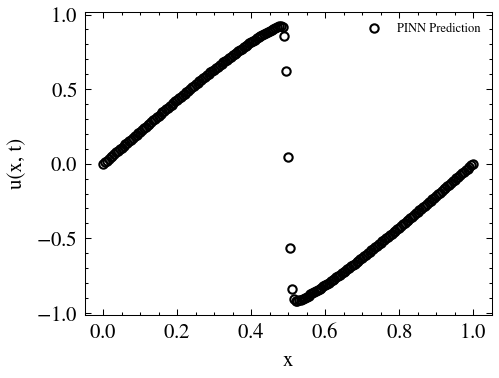

In [10]:

# Predict at a chosen time 
t = 0.3
x_test = x
t_test = np.full_like(x_test,t * time)
x_test = x_test.reshape(-1, 1)
t_test = t_test.reshape(-1, 1)
u_pred = model(tf.concat([x_test, t_test], axis=1)).numpy()
# np.savetxt(f"./temp/u_burger_PINN_{t}.txt", u_pred)

# Exact solution
# u_exact = exact_riemann_solution(x, t)

# Plot
# plt.plot(x_test, u_exact, label='Exact')
# plt.plot(x_test, u_initial_sine(x_test), '-', label='Initial Condition')
plt.plot(x_test, u_pred, 'o', mfc='None', mec='black', ms = 4, label='PINN Prediction')

# plt.title(f'Solution at t = {t * time:.2f}')
plt.xlabel('x'); plt.ylabel('u(x, t)')
plt.legend(fontsize=6, loc='upper right')
# plt.savefig("solution0.3_pinn_vs_dyn.pdf")
plt.show()



In [11]:
# Print a summary of layers and their weights
for i, layer in enumerate(model.net.layers):
    # print(f"Layer {i}: {layer.name}")
    print(f"Layer {i}")

    weights = layer.weights
    if weights:
        print(f"  - Weight shape: {weights[0].shape}")
    else:
        print("  - No weights")


Layer 0
  - Weight shape: (2, 100)
Layer 1
  - Weight shape: (100, 100)
Layer 2
  - Weight shape: (100, 100)
Layer 3
  - Weight shape: (100, 100)
Layer 4
  - Weight shape: (100, 100)
Layer 5
  - Weight shape: (100, 100)
Layer 6
  - Weight shape: (100, 100)
Layer 7
  - Weight shape: (100, 100)
Layer 8
  - Weight shape: (100, 1)
